In [6]:
# Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
# Reading the data and converting into dataframe
df = pd.read_csv("data/train.csv")

In [7]:
# Printing first 5 rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Profiling the data

### shape, column types, and missingness per column.

In [10]:
# Shape
df.shape

(891, 12)

In [13]:
# Column details
list(df.columns) 
# used list for better visualization

['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked']

# Data Type of each column


In [16]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [17]:
# No need to change the datatype of any column

In [15]:
# number of rows,column names, non-null values, data types, memory usage by info()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [18]:
# interpretation
# Age :- In age , 891 - 714 = 177 enteries are missing , which is 19.9% of data we can't remove the 19.9% of data.That's why we should impute the age by median.
# Cabin :- In Cabin column,  891 - 204 = 687 enteries are missing , which is 77.1% of data of cabin ,Filling that much of data by median or mode will be a stupid idea , so we will drop the column cabin.
# Embarked : 2 enteries are missing,The two missing Embarked values should be replaced with the mode because the missing proportion is negligible and Embarked is categorical.

In [19]:
# Checking the duplicates
df.duplicated().sum()

np.int64(0)

In [20]:
# Means duplicated row found = 0

### Outliers

In [21]:
# Basic stats of numerical columns
df[["Age", "Fare", "SibSp", "Parch"]].describe()

,Age,Fare,SibSp,Parch
count,714.000000,891.000000,891.000000,891.000000
mean,29.699118,32.204208,0.523008,0.381594
std,14.526497,49.693429,1.102743,0.806057
min,0.420000,0.000000,0.000000,0.000000
25%,20.125000,7.910400,0.000000,0.000000
50%,28.000000,14.454200,0.000000,0.000000
75%,38.000000,31.000000,1.000000,0.000000
max,80.000000,512.329200,8.000000,6.000000


In [22]:
# calculating outlier for fare
Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

fare_outliers = df[
    (df["Fare"] < lower_bound) |
    (df["Fare"] > upper_bound)
]

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of outliers:", len(fare_outliers))

Lower Bound: -26.724
Upper Bound: 65.6344
Number of outliers: 116


In [23]:
# Analysing the outliers
fare_outliers["Fare"].sort_values()

151     66.6000
336     66.6000
369     69.3000
641     69.3000
201     69.5500
         ...   
341    263.0000
438    263.0000
258    512.3292
679    512.3292
737    512.3292
Name: Fare, Length: 116, dtype: float64

In [26]:
df[df["Fare"] > 263][
    ["PassengerId", "Survived", "Pclass", "Name", "Ticket", "Fare"]
].sort_values("Fare")

,PassengerId,Survived,Pclass,Name,Ticket,Fare
258,259,1,1,"Ward, Miss. Anna",PC 17755,512.3292
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",PC 17755,512.3292
737,738,1,1,"Lesurer, Mr. Gustave J",PC 17755,512.3292


In [ ]:
# Form this we should not remove the outliers in fare like "512.3292" because this can be a genuine fair price , ticket "PC 17755" has same fare for all enteries

In [27]:
# Cheking if a ticket having different values
ticket_fare_check = (
    df.groupby("Ticket")["Fare"]
      .nunique()
      .sort_values(ascending=False)
)

ticket_fare_check.head(20)

Ticket
7534                 2
367655               1
368323               1
36864                1
36865                1
36866                1
368703               1
36928                1
36947                1
36963                1
36967                1
STON/O 2. 3101293    1
370129               1
370365               1
370369               1
370370               1
370371               1
370372               1
370373               1
370375               1
Name: Fare, dtype: int64

In [30]:
# Ticket = "7534" has two prices, identifying further
df[df["Ticket"] == "7534"][
    ["PassengerId", "Name", "Ticket", "Fare", "Pclass", "Sex", "Age"]
]


,PassengerId,Name,Ticket,Fare,Pclass,Sex,Age
138,139,"Osen, Mr. Olaf Elon",7534,9.2167,3,male,16.0
876,877,"Gustafsson, Mr. Alfred Ossian",7534,9.8458,3,male,20.0


In [31]:
#The Ticket field is not perfectly consistent with Fare, as ticket 7534 appears with two different fare values. This inconsistency should be investigated before using Ticket-Fare relationships for modeling or feature engineering.

In [35]:
# Handling outliers for SibSp
# IQR
Q1 = 0
Q3 = 1
IQR = Q3 - Q1
# Upper bound
Upper_Bound = Q3 + 1.5 * IQR
Lower_Bound = Q1 - 1.5 * IQR
print(Upper_Bound)
print(Lower_Bound)

2.5
-1.5


In [36]:
sibsp_outliers = df[df["SibSp"] > 2.5]

print("Number of SibSp outliers:", len(sibsp_outliers))
print(sibsp_outliers["SibSp"].value_counts().sort_index())

Number of SibSp outliers: 46
SibSp
3    16
4    18
5     5
8     7
Name: count, dtype: int64


In [38]:
# Handling outliers for SibSp
# IQR
Q1 = 0
Q3 = 0
IQR = Q3 - Q1
# Upper bound
Upper_Bound = Q3 + 1.5 * IQR
Lower_Bound = Q1 - 1.5 * IQR
print(Upper_Bound)
print(Lower_Bound)

0.0
0.0


In [39]:
# Check the frequency of each Parch value
df["Parch"].value_counts().sort_index()

Parch
0    678
1    118
2     80
3      5
4      4
5      5
6      1
Name: count, dtype: int64

In [40]:
# Parch was treated as a discrete relationship-count variable rather than a continuous variable, so IQR-based outlier removal was not applied. Its observed values were retained because they represent plausible family relationships.

## Actual problems in dataset

# Data Cleaning

## Age Missing Value


In [41]:
# 891 total
# 714 available
# 177 missing
# Calculate the median age before imputation
age_median = df["Age"].median()

print("Median Age:", age_median)

Median Age: 28.0


In [42]:
# Replace missing Age values with the median
df["Age"] = df["Age"].fillna(age_median)

In [43]:
# Verify that Age has no missing values
df["Age"].isnull().sum()

np.int64(0)

In [53]:
# Age missing values were replaced with the median to retain observations while reducing the influence of extreme ages.

## Missing Embarked

In [46]:
# Total = 891
# Missing = 2
# Missing % ≈ 0.22%

In [47]:
# Embarked is a categorical varriable , that's why we use mode rather than median

In [48]:
# Find the most frequent Embarked category
embarked_mode = df["Embarked"].mode()[0]

print("Mode of Embarked:", embarked_mode)

Mode of Embarked: S


In [49]:
# Replace missing Embarked values with the mode
df["Embarked"] = df["Embarked"].fillna(embarked_mode)

In [50]:
# Verify that Embarked has no missing values
df["Embarked"].isnull().sum()

np.int64(0)

## Cabin

In [51]:
# Drop Cabin because of excessive missingness
df = df.drop(columns=["Cabin"])

In [54]:
# Cabin was dropped because approximately 77% of its values are missing, making reliable imputation impractical and potentially introducing artificial information.

In [55]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')

In [56]:
# Check remaining missing values after cleaning
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [58]:
# No need to remove the outliers
# Most of the data is cleaned and all the reuqire changes are made


## Validation of clean data

In [59]:
# Check the shape after cleaning
df.shape

(891, 11)

In [60]:
# Check for remaining missing values
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [61]:
# Confirm that there are no duplicate rows
df.duplicated().sum()

np.int64(0)

In [62]:
# Verify the data types after cleaning
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Embarked        object
dtype: object

In [63]:
# Verify the data types after cleaning
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Embarked        object
dtype: object

In [64]:
# Review the cleaned dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


# Exploratory Data Analysis


## Overall Survival

**Question:** What proportion of passengers survived the Titanic disaster?

In [65]:
# Count passengers by survival status
survival_counts = df["Survived"].value_counts().sort_index()

survival_counts

Survived
0    549
1    342
Name: count, dtype: int64

In [66]:
# 0 → Did not survive
# 1 → Survived

In [68]:
# Calculate the percentage of passengers in each survival category
survival_percentage = (
    df["Survived"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

survival_percentage

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

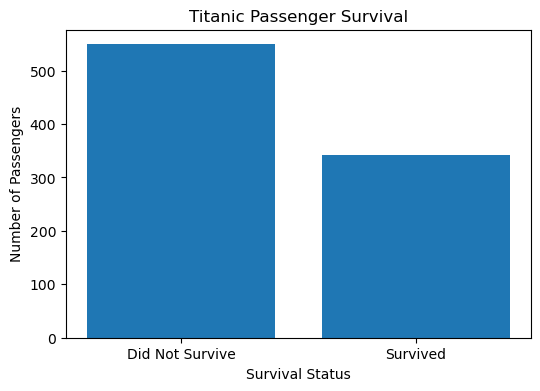

In [69]:
# Visualize overall survival
plt.figure(figsize=(6, 4))

plt.bar(
    ["Did Not Survive", "Survived"],
    survival_counts.values
)

plt.xlabel("Survival Status")
plt.ylabel("Number of Passengers")
plt.title("Titanic Passenger Survival")

plt.show()

**Interpretation:** Approximately 38% of passengers survived, while about 62% did not. This establishes the overall survival rate as a baseline for comparing survival across passenger characteristics.

# Passenger Class vs Survival

**Question:** Did passenger class affect the likelihood of survival?

In [70]:
# Calculate survival rate for each passenger class
survival_by_class = df.groupby("Pclass")["Survived"].mean() * 100

survival_by_class

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

In [71]:
# why .mean()?

# 0 = No
# 1 = Yes

# (1 + 1 + 0 + 0 + 1) / 5 = 0.60
# mean*100 = 60%


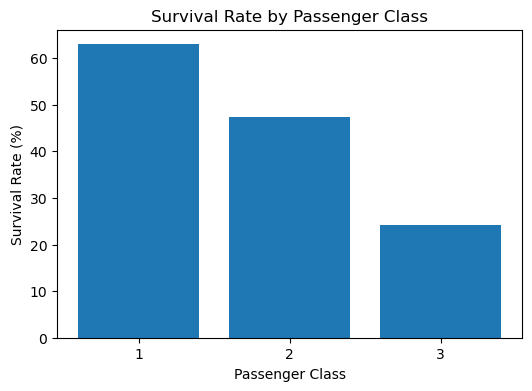

In [72]:
# Visualize survival rate by passenger class
plt.figure(figsize=(6, 4))

plt.bar(
    survival_by_class.index.astype(str),
    survival_by_class.values
)

plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")
plt.title("Survival Rate by Passenger Class")

plt.show()

**Interpretation:** Survival rates differed substantially across passenger classes, with first-class passengers having the highest survival rate and third-class passengers having the lowest. This suggests that passenger class was strongly associated with survival in the dataset.

# Sex vs Survival 
**Question:** Did survival rates differ between male and female passengers?

In [73]:
# Calculate survival rate for each sex
survival_by_sex = df.groupby("Sex")["Survived"].mean() * 100

survival_by_sex

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

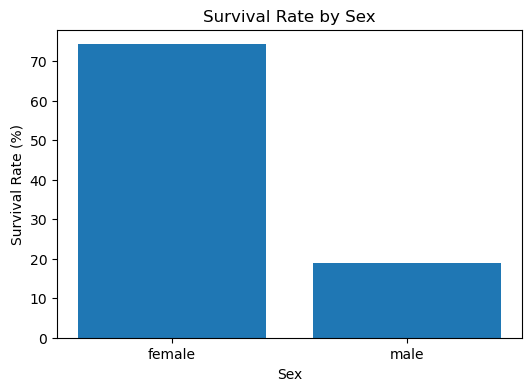

In [74]:
# Visualize survival rate by sex
plt.figure(figsize=(6, 4))

plt.bar(
    survival_by_sex.index,
    survival_by_sex.values
)

plt.xlabel("Sex")
plt.ylabel("Survival Rate (%)")
plt.title("Survival Rate by Sex")

plt.show()

**Interpretation:** Survival rates differed substantially by sex, with female passengers having a much higher survival rate than male passengers. This indicates a strong association between sex and survival in the dataset.

# Sex + Passenger Class vs Survival
**Question:** How did survival differ by both sex and passenger class?

In [77]:
# Calculate survival rate by passenger class and sex
survival_by_class_sex = (
    df.groupby(["Pclass", "Sex"])["Survived"]
    .mean()
    .unstack()
    * 100
)

survival_by_class_sex

Sex,female,male
Pclass,,
1,96.808511,36.885246
2,92.105263,15.740741
3,50.000000,13.544669


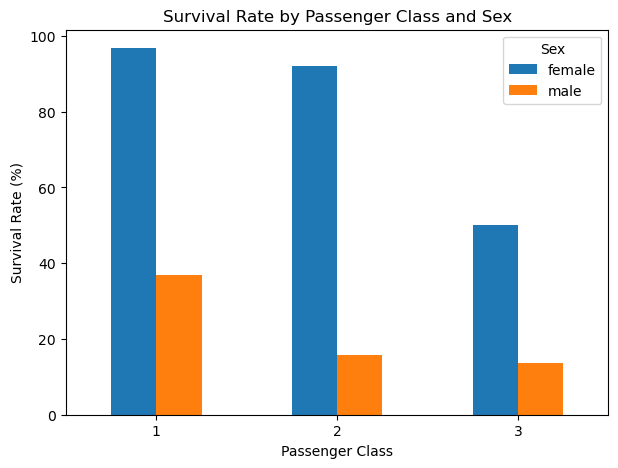

In [80]:
# Plot survival rate by passenger class and sex
survival_by_class_sex.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")
plt.title("Survival Rate by Passenger Class and Sex")
plt.xticks(rotation=0)
plt.legend(title="Sex")

plt.show()

**Interpretation:** Survival differed strongly across both sex and passenger class. Female passengers had substantially higher survival rates than males within every passenger class, while survival generally decreased from first class to third class. The combination of sex and passenger class therefore provides more detailed information about survival than either variable considered alone.

# Age Distribution and Survival

**Question:** How does passenger age differ between survivors and non-survivors?

In [81]:
# Compare age statistics between survivors and non-survivors
df.groupby("Survived")["Age"].describe()

,count,mean,std,min,25%,50%,75%,max
Survived,,,,,,,,
0,549.0,30.028233,12.499986,1.00,23.0,28.0,35.0,74.0
1,342.0,28.291433,13.764425,0.42,21.0,28.0,35.0,80.0


In [83]:
# Compare median age by survival status
df.groupby("Survived")["Age"].median()

Survived
0    28.0
1    28.0
Name: Age, dtype: float64

In [ ]:
# Age distributions for survivors and non-survivors overlap substantially, with both groups having a median age of 28. Survivors were slightly younger on average, but age alone does not clearly separate the two groups.

<Figure size 700x500 with 0 Axes>

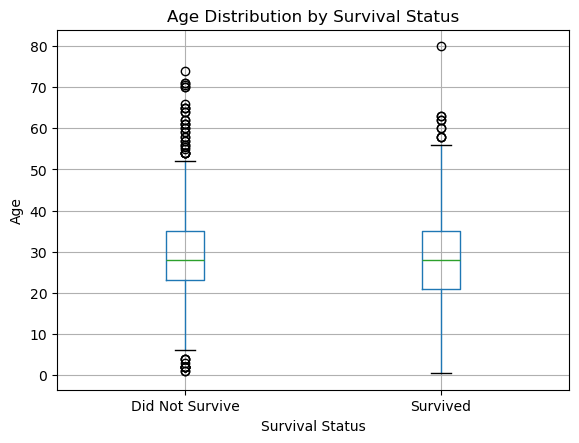

In [86]:
plt.figure(figsize=(7, 5))

df.boxplot(
    column="Age",
    by="Survived"
)

plt.xlabel("Survival Status")
plt.ylabel("Age")
plt.title("Age Distribution by Survival Status")

plt.suptitle("")
plt.xticks([1, 2], ["Did Not Survive", "Survived"])

plt.show()

**Visualization Interpretation:** The age distributions of survivors and non-survivors overlap substantially, with both groups having a median age of 28. Survivors were slightly younger on average, but age alone does not clearly separate the two groups.

**Data-quality note:** The 177 missing Age values were imputed using the median age of 28. This may have slightly influenced the age distribution and should be considered when interpreting age-related patterns or using Age for modeling.

# Fare and Survival

**Question:** Is Fare associated with survival?

In [88]:
# Compare fare statistics between survivors and non-survivors
df.groupby("Survived")["Fare"].describe()

,count,mean,std,min,25%,50%,75%,max
Survived,,,,,,,,
0,549.0,22.117887,31.388207,0.0,7.8542,10.5,26.0,263.0000
1,342.0,48.395408,66.596998,0.0,12.4750,26.0,57.0,512.3292


<Figure size 700x500 with 0 Axes>

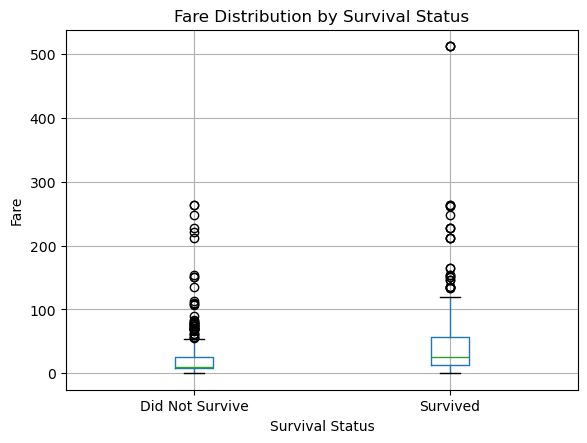

In [90]:
# Compare fare distributions between survivors and non-survivors
plt.figure(figsize=(7, 5))

df.boxplot(
    column="Fare",
    by="Survived"
)

plt.xlabel("Survival Status")
plt.ylabel("Fare")
plt.title("Fare Distribution by Survival Status")

plt.suptitle("")
plt.xticks([1, 2], ["Did Not Survive", "Survived"])

plt.show()

**Interpretation:** Survivors generally had higher ticket fares than non-survivors, with a higher median fare and a wider upper range. This suggests that fare was associated with survival and may partly reflect differences in passenger class.

# Key Insights

### Insight 1 — Sex and passenger class jointly shaped survival

Survival differed substantially across both sex and passenger class. Female passengers had much higher survival rates than male passengers within each class, but female survival also decreased from first class to third class. This shows that looking at sex or passenger class individually does not capture the full survival pattern.

### Insight 2 — Age was not a strong separator of survival

Survivors and non-survivors had the same median age of 28 years and substantially overlapping age distributions. Survivors were slightly younger on average (28.29 years compared with 30.03 years), but the small difference and large overlap suggest that age alone did not clearly distinguish survivors from non-survivors.

### Insight 3 — Higher fares were associated with higher survival

Survivors generally paid higher fares than non-survivors, with a higher median fare and a wider upper range. At the extreme end, all three passengers with the maximum recorded fare of 512.3292 survived, while survival among zero-fare passengers was extremely uncommon. However, these extreme groups are very small, and the relationship between Fare and survival may partly reflect differences in passenger class.

# Data Quality & Modeling Risks

### Data-quality risk — Ticket/Fare inconsistency

Ticket `7534` appears with two different Fare values (9.2167 and 9.8458). This may represent a legitimate fare-recording difference, but it should be investigated before using Ticket and Fare together for feature engineering or modeling. No correction was made because there was insufficient evidence to determine which value, if any, was incorrect.

### Modeling leakage risk — Target variable

`Survived` is the target variable and must not be included as an input feature when building a predictive model. Including it during training would expose the outcome directly to the model and produce misleadingly strong performance.

### Modeling consideration — Age imputation

The 177 missing Age values were replaced with the median age of 28. This preserves the observations but reduces natural variation and may influence age-related patterns or model predictions.